In [32]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.seasonal import seasonal_decompose
from sklearn.metrics import root_mean_squared_error
from statsmodels.tsa.api import SimpleExpSmoothing
from statsmodels.tsa.holtwinters import ExponentialSmoothing
from torch.distributions import Exponential
import os
os.chdir(r'C:\Users\dai\Downloads\Datasets\Datasets')

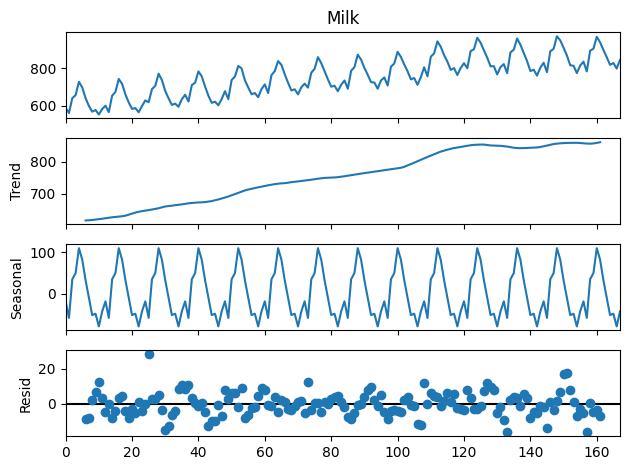

In [2]:
df=pd.read_csv('monthly-milk-production-pounds-p.csv')
series=df['Milk']
result=seasonal_decompose(series,model='additive',period=12)
result.plot()
plt.show()

<Figure size 800x1200 with 0 Axes>

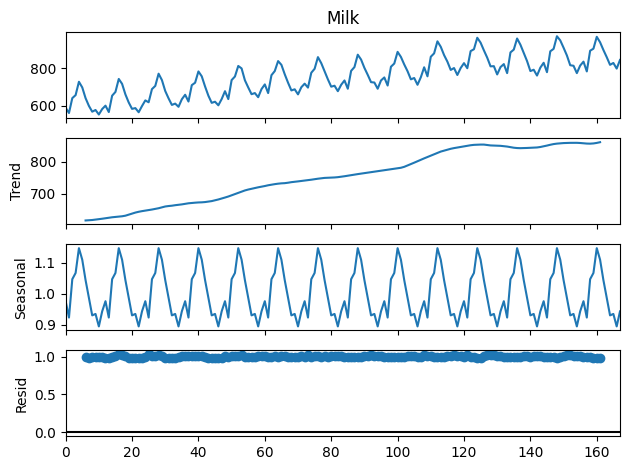

In [3]:
df=pd.read_csv('monthly-milk-production-pounds-p.csv')
series=df['Milk']
result=seasonal_decompose(series,model='multiplicative',period=12)
plt.figure(figsize=(8,12))
result.plot()
plt.show()

### Centered Rolling Mean

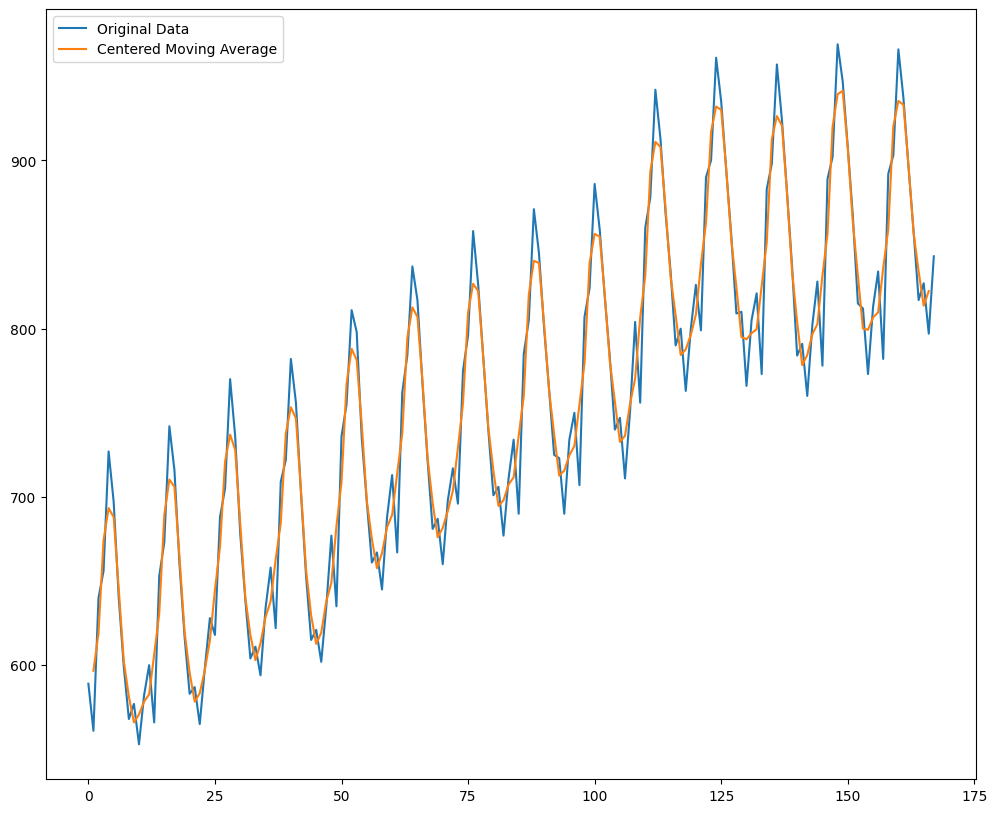

In [4]:
y=df['Milk']
fcast=y.rolling(3,center=True).mean()
plt.figure(figsize=(12,10))
plt.plot(y,label='Original Data')
plt.plot(fcast,label='Centered Moving Average')
plt.legend(loc='best')
plt.show()

### Trailing Moving Average

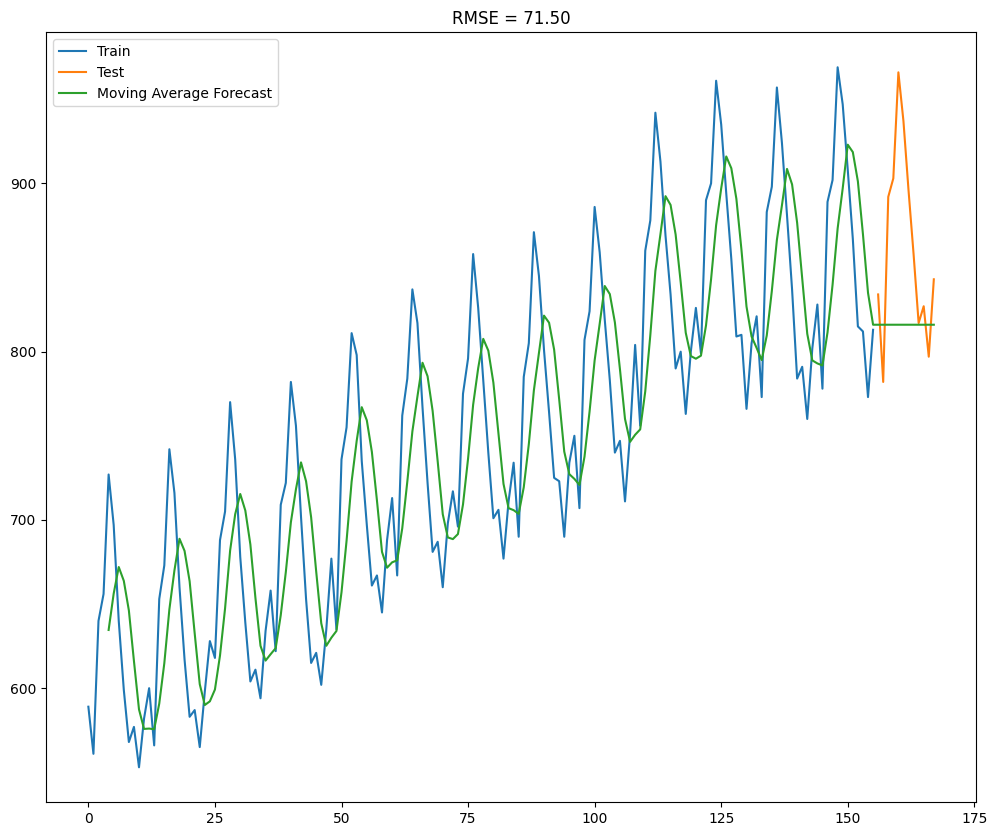

In [5]:
y_train=df['Milk'].iloc[:-12]
y_test=df['Milk'].iloc[-12:]
span=5
fcast=y_train.rolling(span).mean()
MA=fcast.iloc[-1]
MA_series=pd.Series(MA.repeat(len(y_test)))
MA_fcast=pd.concat([fcast,MA_series],ignore_index=True)
rmse=root_mean_squared_error(y_test,MA_series)
plt.figure(figsize=(12,10))
plt.plot(y_train,label='Train')
plt.plot(y_test,label='Test')
plt.title(f'RMSE = {rmse:.2f}')
plt.plot(MA_fcast,label='Moving Average Forecast')

plt.legend(loc='best')
plt.show()

In [6]:
MA_series

0     816.0
1     816.0
2     816.0
3     816.0
4     816.0
5     816.0
6     816.0
7     816.0
8     816.0
9     816.0
10    816.0
11    816.0
dtype: float64

### Simple Exponential Smoothing

C:\Users\dai\PycharmProjects\ML\.venv\Lib\site-packages\pandas\util\_decorators.py:213: EstimationWarning: Model has no free parameters to estimate. Set optimized=False to suppress this warning
  return func(*args, **kwargs)


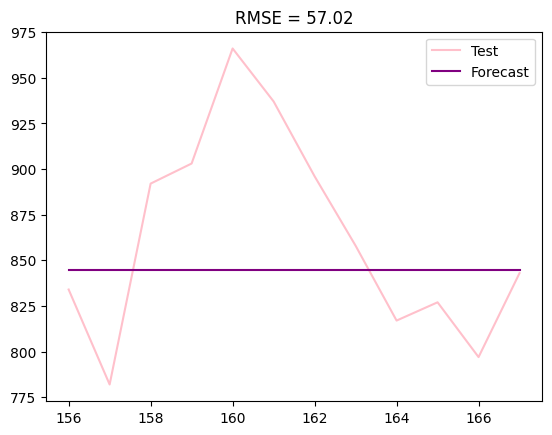

In [7]:
ses=SimpleExpSmoothing(y_train)
alpha=0.1
fit1=ses.fit(smoothing_level=alpha)
fcast1=fit1.forecast(len(y_test))
y_test.plot(color='pink',label='Test')
fcast1.plot(color='purple',label='Forecast')
rmse=root_mean_squared_error(y_test,fcast1)
plt.title(f'RMSE = {rmse:.2f}')
plt.legend(loc='best')
plt.show()

In [8]:
from ipywidgets import interact,widgets
ses=SimpleExpSmoothing(y_train)
def simple_exp(alpha):
    fit1=ses.fit(smoothing_level=alpha)
    fcast1=fit1.forecast(len(y_test))
    y_test.plot(color='pink',label='Test')
    fcast1.plot(color='purple',label='Forecast')
    rmse=root_mean_squared_error(y_test,fcast1)
    plt.title(f'RMSE = {rmse:.2f}, alpha = {alpha:.2f}')
    plt.legend(loc='best')
    plt.show()
widgets.interact(simple_exp,alpha=(0.01,1,0.01))


interactive(children=(FloatSlider(value=0.5, description='alpha', max=1.0, min=0.01, step=0.01), Output()), _d…

<function __main__.simple_exp(alpha)>

## Holt's Linear Trend

In [9]:
from statsmodels.tsa.api import Holt

C:\Users\dai\PycharmProjects\ML\.venv\Lib\site-packages\pandas\util\_decorators.py:213: EstimationWarning: Model has no free parameters to estimate. Set optimized=False to suppress this warning
  return func(*args, **kwargs)


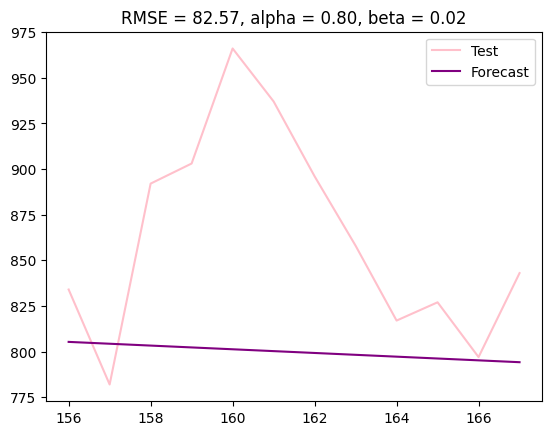

In [10]:
alpha = 0.8
beta = 0.02
holt = Holt(y_train)
fit1 = holt.fit(smoothing_level=alpha, smoothing_trend=beta)
fcast1 = fit1.forecast(len(y_test))
y_test.plot(color='pink',label='Test')
fcast1.plot(color='purple',label='Forecast')
rmse=root_mean_squared_error(y_test,fcast1)
plt.title(f'RMSE = {rmse:.2f}, alpha = {alpha:.2f}, beta = {beta:.2f}')
plt.legend(loc='best')
plt.show()

In [11]:
holt = Holt(y_train)
def holt_linear(alpha, beta):
    fit1 = holt.fit(smoothing_level=alpha, smoothing_trend=beta)
    fcast1 = fit1.forecast(len(y_test))
    y_test.plot(color='pink',label='Test')
    fcast1.plot(color='purple',label='Forecast')
    rmse=root_mean_squared_error(y_test,fcast1)
    plt.title(f'RMSE = {rmse:.2f}, alpha = {alpha:.2f}, beta = {beta:.2f}')
    plt.legend(loc='best')
    plt.show()
widgets.interact(holt_linear,alpha=(0.01,1,0.01), beta=(0.01,1,0.01))

interactive(children=(FloatSlider(value=0.5, description='alpha', max=1.0, min=0.01, step=0.01), FloatSlider(v…

<function __main__.holt_linear(alpha, beta)>

In [12]:
holt = Holt(y_train, exponential=True)
def holt_exp(alpha, beta):
    fit1 = holt.fit(smoothing_level=alpha, smoothing_trend=beta)
    fcast1 = fit1.forecast(len(y_test))
    y_test.plot(color='pink',label='Test')
    fcast1.plot(color='purple',label='Forecast')
    rmse=root_mean_squared_error(y_test,fcast1)
    plt.title(f'RMSE = {rmse:.2f}, alpha = {alpha:.2f}, beta = {beta:.2f}')
    plt.legend(loc='best')
    plt.show()
widgets.interact(holt_exp,alpha=(0.01,1,0.01), beta=(0.01,1,0.01))

interactive(children=(FloatSlider(value=0.5, description='alpha', max=1.0, min=0.01, step=0.01), FloatSlider(v…

<function __main__.holt_exp(alpha, beta)>

In [13]:
def holt_both(alpha, beta, exponentiality):
    holt = Holt(y_train, exponential=exponentiality)
    fit1 = holt.fit(smoothing_level=alpha, smoothing_trend=beta)
    fcast1 = fit1.forecast(len(y_test))
    y_test.plot(color='pink',label='Test')
    fcast1.plot(color='purple',label='Forecast')
    rmse=root_mean_squared_error(y_test,fcast1)
    plt.title(f'RMSE = {rmse:.2f}, alpha = {alpha:.2f}, beta = {beta:.2f}')
    plt.legend(loc='best')
    plt.show()
widgets.interact(holt_both,alpha=(0.01,1,0.01), beta=(0.01,1,0.01), exponentiality = [True, False])

interactive(children=(FloatSlider(value=0.5, description='alpha', max=1.0, min=0.01, step=0.01), FloatSlider(v…

<function __main__.holt_linear(alpha, beta, exponentiality)>

## Damped Methods

In [14]:
def damped(alpha, beta, phi, exponentiality, dampness):
    holt = Holt(y_train, exponential=exponentiality, damped_trend=dampness)
    fit1 = holt.fit(smoothing_level=alpha, smoothing_trend=beta, damping_trend=phi)
    fcast1 = fit1.forecast(len(y_test))
    y_test.plot(color='pink',label='Test')
    fcast1.plot(color='purple',label='Forecast')
    rmse=root_mean_squared_error(y_test,fcast1)
    plt.title(f'RMSE = {rmse:.2f}, alpha = {alpha:.2f}, beta = {beta:.2f}')
    plt.legend(loc='best')
    plt.show()
widgets.interact(damped,alpha=(0.01,1,0.01), beta=(0.01,1,0.01), phi=(0.01,1,0.01), exponentiality = [True, False], dampness = [True, False])

interactive(children=(FloatSlider(value=0.5, description='alpha', max=1.0, min=0.01, step=0.01), FloatSlider(v…

<function __main__.damped(alpha, beta, phi, exponentiality, dampness)>

In [25]:
def hw(alpha, beta, gamma, seasonality, periods=12):
    holt = ExponentialSmoothing(y_train, trend='add', seasonal=seasonality, seasonal_periods=periods)
    fit1 = holt.fit(smoothing_level=alpha, smoothing_trend=beta, smoothing_seasonal = gamma)
    fcast1 = fit1.forecast(len(y_test))
    y_test.plot(color='pink',label='Test')
    fcast1.plot(color='purple',label='Forecast')
    rmse=root_mean_squared_error(y_test,fcast1)
    plt.title(f'RMSE = {rmse:.2f}, alpha = {alpha:.2f}, beta = {beta:.2f}, gamma = {gamma:.2f}')
    plt.legend(loc='best')
    plt.show()
widgets.interact(hw,alpha=(0.01,1,0.01), beta=(0.01,1,0.01), gamma=(0.01,1,0.01), seasonality = ['add', 'mul'])

interactive(children=(FloatSlider(value=0.5, description='alpha', max=1.0, min=0.01, step=0.01), FloatSlider(v…

<function __main__.hw(alpha, beta, gamma, seasonality, periods=12)>

<Axes: xlabel='Date'>

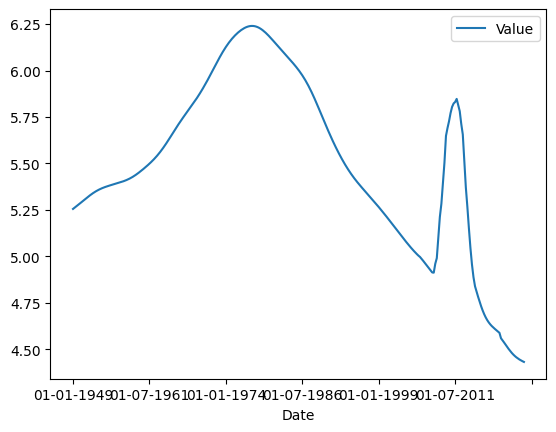

In [30]:
fred = pd.read_csv('FRED-NROUST.csv')
fred.plot(kind='line', x='Date', y='Value')

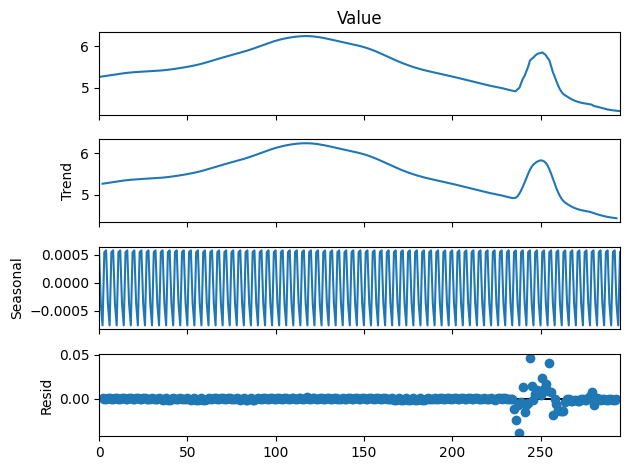

In [31]:
fred = pd.read_csv('FRED-NROUST.csv')
series=fred['Value']
result=seasonal_decompose(series,model='additive',period=4)
result.plot()
plt.show()

In [33]:
y_train = fred['Value'].iloc[:-8]
y_test = fred['Value'].iloc[-8:]

In [35]:
def holt_both(alpha, beta, exponentiality):
    holt = Holt(y_train, exponential=exponentiality)
    fit1 = holt.fit(smoothing_level=alpha, smoothing_trend=beta)
    fcast1 = fit1.forecast(len(y_test))
    y_test.plot(color='pink',label='Test')
    fcast1.plot(color='purple',label='Forecast')
    rmse=root_mean_squared_error(y_test,fcast1)
    plt.title(f'RMSE = {rmse:.5f}, alpha = {alpha:.2f}, beta = {beta:.2f}')
    plt.legend(loc='best')
    plt.show()
widgets.interact(holt_both,alpha=(0.01,1,0.01), beta=(0.01,1,0.01), exponentiality = [True, False])

interactive(children=(FloatSlider(value=0.5, description='alpha', max=1.0, min=0.01, step=0.01), FloatSlider(v…

<function __main__.holt_both(alpha, beta, exponentiality)>